## Data Preparation and Exploratory Analysis of Economy-Related YouTube Comments

### Project Overview

This notebook continues the project by cleaning, inspecting, and analyzing the YouTube comment dataset collected in the previous stage.

The goal is to prepare the dataset for downstream text analysis while also exploring early patterns in engagement, tokenization behavior, sentiment, LIWC-based language features, and temporal trends in public discussion of U.S. economy-related videos.

### Data Inspection and Cleaning

#### Initial Data Inspection

Before cleaning the dataset, I inspect its structure, size, and major fields in order to understand what kinds of preprocessing will be necessary.

This first pass focuses on identifying common data issues such as formatting inconsistencies, text irregularities, datetime readability problems, missing values, duplicates, and platform-specific noise in YouTube comments.

In [1]:
import pandas as pd
df = pd.read_csv('yt_comments.csv')

In [2]:
# first 10 rows
df.head(10)

,channel_name,video_id,video_title,video_creation_time,video_number_of_views,comment_id,comment_title,comment_creation_time,comment_number_of_likes
0,CNN,L5tvym36mO0,Gold surges to record $5000 price,2026-01-26T15:32:49Z,51869,Ugwe-foTG3moc3xxtrd4AaABAg,America is toast,2026-01-26T15:34:36Z,98
1,CNN,L5tvym36mO0,Gold surges to record $5000 price,2026-01-26T15:32:49Z,51869,Ugyou95rzVIIpfOBBpR4AaABAg,He's going for the YUGest bankruptcy of his li...,2026-01-26T15:41:47Z,35
2,CNN,L5tvym36mO0,Gold surges to record $5000 price,2026-01-26T15:32:49Z,51869,Ugy1uAYCCiQLEkcgz4F4AaABAg,Gold only surge when economic not stable,2026-01-26T15:35:51Z,44
3,CNN,L5tvym36mO0,Gold surges to record $5000 price,2026-01-26T15:32:49Z,51869,UgzjmzQUiJf5Dyxz73Z4AaABAg,Because the world doesn’t trust the US dollar ...,2026-01-26T15:44:13Z,91
4,CNN,L5tvym36mO0,Gold surges to record $5000 price,2026-01-26T15:32:49Z,51869,UgzZIZEgQGeu38XsEB14AaABAg,We were told this day would come! Invest in go...,2026-01-26T16:09:36Z,10
5,CNN,L5tvym36mO0,Gold surges to record $5000 price,2026-01-26T15:32:49Z,51869,Ugwo2oTDhujLjjBZmlh4AaABAg,Wonder how much gold trump has right now and s...,2026-01-26T16:03:29Z,11
6,CNN,L5tvym36mO0,Gold surges to record $5000 price,2026-01-26T15:32:49Z,51869,UgwfTU5wBSHxKTW0s-94AaABAg,Donald Trump is literally collapsing the US in...,2026-01-26T15:44:14Z,79
7,CNN,L5tvym36mO0,Gold surges to record $5000 price,2026-01-26T15:32:49Z,51869,Ugw1i74qmqltTgjgiEh4AaABAg,We were warned if you ever watched The apprent...,2026-01-27T01:39:08Z,2
8,CNN,L5tvym36mO0,Gold surges to record $5000 price,2026-01-26T15:32:49Z,51869,UgzW4dH0K7NdZxLgU2F4AaABAg,Thank you Trump. America is now your seventh b...,2026-01-26T16:16:00Z,22
9,CNN,L5tvym36mO0,Gold surges to record $5000 price,2026-01-26T15:32:49Z,51869,Ugyj_vFA_MbqQHQIj5h4AaABAg,DJT's entire family fortune needs to be sold t...,2026-01-26T17:06:22Z,7


In [3]:
# last 10 rows
df.tail(10)

,channel_name,video_id,video_title,video_creation_time,video_number_of_views,comment_id,comment_title,comment_creation_time,comment_number_of_likes
2950,Fox News,xOL8HI4aKlE,"Voter panel CLASHES over economy, looming shut...",2025-11-03T19:45:05Z,371452,UgwHijvM6Dc5Yr6Zcf94AaABAg,No one needs genital mutilation to survive.,2025-11-03T21:10:47Z,271
2951,Fox News,xOL8HI4aKlE,"Voter panel CLASHES over economy, looming shut...",2025-11-03T19:45:05Z,371452,Ugyl4tovz4PiOYIKXTR4AaABAg,Did that brother really say his family has bee...,2025-11-10T12:41:01Z,1
2952,Fox News,xOL8HI4aKlE,"Voter panel CLASHES over economy, looming shut...",2025-11-03T19:45:05Z,371452,UgzprXwHzcKQrUWEytN4AaABAg,The gentleman said it brilliantly…we can be ki...,2025-11-03T22:18:18Z,92
2953,Fox News,xOL8HI4aKlE,"Voter panel CLASHES over economy, looming shut...",2025-11-03T19:45:05Z,371452,Ugwwl5a1WZAntkuGaKt4AaABAg,If you consider illegal immigration is your ne...,2025-11-03T20:28:32Z,90
2954,Fox News,xOL8HI4aKlE,"Voter panel CLASHES over economy, looming shut...",2025-11-03T19:45:05Z,371452,Ugy8o0EBEAdYeVE7c3N4AaABAg,GOP BETTER GET ON THE UNEMPLOYMENT LINE BECAUS...,2025-11-04T16:50:37Z,1
2955,Fox News,xOL8HI4aKlE,"Voter panel CLASHES over economy, looming shut...",2025-11-03T19:45:05Z,371452,Ugwf4XI8-3yPlrciBDx4AaABAg,This is REDICULOUS. Enough with the freebies f...,2025-11-03T20:16:57Z,133
2956,Fox News,xOL8HI4aKlE,"Voter panel CLASHES over economy, looming shut...",2025-11-03T19:45:05Z,371452,Ugy1BegOzzcb7KDVVI14AaABAg,The five to put their hand up for their neighb...,2025-11-03T20:11:50Z,103
2957,Fox News,xOL8HI4aKlE,"Voter panel CLASHES over economy, looming shut...",2025-11-03T19:45:05Z,371452,UgxeZFTigI-0GpE7J9l4AaABAg,I will never trust ANYTHING coming from Flop🦊N...,2025-11-09T19:54:37Z,7
2958,Fox News,xOL8HI4aKlE,"Voter panel CLASHES over economy, looming shut...",2025-11-03T19:45:05Z,371452,Ugx4b_Uga8f9TXavSd54AaABAg,The 2 black guy’s here are the strongest think...,2025-11-03T20:08:21Z,75
2959,Fox News,xOL8HI4aKlE,"Voter panel CLASHES over economy, looming shut...",2025-11-03T19:45:05Z,371452,UgzP5Km6yNXRBwLeOW94AaABAg,Where do they find these ppl with no common se...,2025-11-03T21:25:38Z,16


In [4]:
# how many rows and columns
df.shape

(2960, 9)

In [5]:
# take a look at data types
df.dtypes

channel_name               object
video_id                   object
video_title                object
video_creation_time        object
video_number_of_views       int64
comment_id                 object
comment_title              object
comment_creation_time      object
comment_number_of_likes     int64
dtype: object

In [6]:
# take a look at stats
df.describe()

,video_number_of_views,comment_number_of_likes
count,2.960000e+03,2960.000000
mean,1.661890e+05,66.531081
std,2.447521e+05,244.205523
min,6.927000e+03,0.000000
25%,2.838200e+04,2.000000
50%,6.188800e+04,11.000000
75%,1.999900e+05,46.250000
max,1.550615e+06,6098.000000


#### Initial Observations

At this stage, I inspected both the first and last rows of the dataset to understand its overall structure and variation across channels and videos. The data appears relatively clean at a high level, since the major columns contain plausible values and the dataset already preserves both video-level and comment-level context.

Two fields that clearly require preprocessing are `video_creation_time` and `comment_creation_time`. In their raw form, they are not especially readable and are less convenient for time-based analysis, so converting them into standard datetime format is an important early cleaning step.

I also observed that video titles are much more standardized than comment text, which is expected. Titles are written by content producers using relatively consistent conventions, while comments are user-generated and therefore much noisier. This makes the comment field the main target for deeper text cleaning and preprocessing.

#### Cleaning Strategy

After the initial inspection, the next step is to clean the dataset in a way that supports both exploratory analysis and downstream text modeling.

This cleaning process includes standard data-quality checks, datetime conversion, and comment-specific preprocessing steps tailored to noisy YouTube text, such as handling symbols, mentions, and non-alphanumeric content.

**Missing value**

In [7]:
# missing value check
df.isna().sum()

channel_name               0
video_id                   0
video_title                0
video_creation_time        0
video_number_of_views      0
comment_id                 0
comment_title              0
comment_creation_time      0
comment_number_of_likes    0
dtype: int64

No missing values.

**Duplicates**

In [8]:
#duplication check
sum(df.duplicated())

0

No duplications.

**Time conversion**

In [9]:
df['video_creation_time'] = pd.to_datetime(df['video_creation_time']).dt.tz_localize(None)
df['comment_creation_time'] = pd.to_datetime(df['comment_creation_time']).dt.tz_localize(None)

In [10]:
df.head()

,channel_name,video_id,video_title,video_creation_time,video_number_of_views,comment_id,comment_title,comment_creation_time,comment_number_of_likes
0,CNN,L5tvym36mO0,Gold surges to record $5000 price,2026-01-26 15:32:49,51869,Ugwe-foTG3moc3xxtrd4AaABAg,America is toast,2026-01-26 15:34:36,98
1,CNN,L5tvym36mO0,Gold surges to record $5000 price,2026-01-26 15:32:49,51869,Ugyou95rzVIIpfOBBpR4AaABAg,He's going for the YUGest bankruptcy of his li...,2026-01-26 15:41:47,35
2,CNN,L5tvym36mO0,Gold surges to record $5000 price,2026-01-26 15:32:49,51869,Ugy1uAYCCiQLEkcgz4F4AaABAg,Gold only surge when economic not stable,2026-01-26 15:35:51,44
3,CNN,L5tvym36mO0,Gold surges to record $5000 price,2026-01-26 15:32:49,51869,UgzjmzQUiJf5Dyxz73Z4AaABAg,Because the world doesn’t trust the US dollar ...,2026-01-26 15:44:13,91
4,CNN,L5tvym36mO0,Gold surges to record $5000 price,2026-01-26 15:32:49,51869,UgzZIZEgQGeu38XsEB14AaABAg,We were told this day would come! Invest in go...,2026-01-26 16:09:36,10


In [11]:
df.dtypes

channel_name                       object
video_id                           object
video_title                        object
video_creation_time        datetime64[ns]
video_number_of_views               int64
comment_id                         object
comment_title                      object
comment_creation_time      datetime64[ns]
comment_number_of_likes             int64
dtype: object

**Time outliers**

In [12]:
# a video must get created first, then can be commented
df[df['video_creation_time'] >= df['comment_creation_time']]

,channel_name,video_id,video_title,video_creation_time,video_number_of_views,comment_id,comment_title,comment_creation_time,comment_number_of_likes
1569,Fox News,qAMsx2T3ZzE,Trump delivers remarks at the Detroit Economic...,2026-01-13 20:12:51,61164,UgzzMhTXTjHQiNoeLrx4AaABAg,"I strongly hope that the Iranian regime falls,...",2026-01-13 20:11:26,33
2189,Fox News,i-iEZCwL-V8,World Cup ticket prices soar as fans rush to b...,2025-12-11 18:32:01,6927,UgwJNznO8mx_jkWO3zh4AaABAg,Can you imagine...the president of the United ...,2025-12-11 18:30:58,8
2197,Fox News,i-iEZCwL-V8,World Cup ticket prices soar as fans rush to b...,2025-12-11 18:32:01,6927,Ugz1JWhd3oY5oXHCt514AaABAg,"We are gonna win that cup, America is the best...",2025-12-11 18:31:27,1


In [13]:
df = df[df['video_creation_time'] < df['comment_creation_time']]

In [14]:
df.shape

(2957, 9)

Found 3 outlier records and deleted them.

**Numeric outliers**

In [15]:
df['video_number_of_views'].min()

6927

In [16]:
df['comment_number_of_likes'].min()

0

No negative numbers on video views and comment likes.

In [17]:
df.tail(10)

,channel_name,video_id,video_title,video_creation_time,video_number_of_views,comment_id,comment_title,comment_creation_time,comment_number_of_likes
2950,Fox News,xOL8HI4aKlE,"Voter panel CLASHES over economy, looming shut...",2025-11-03 19:45:05,371452,UgwHijvM6Dc5Yr6Zcf94AaABAg,No one needs genital mutilation to survive.,2025-11-03 21:10:47,271
2951,Fox News,xOL8HI4aKlE,"Voter panel CLASHES over economy, looming shut...",2025-11-03 19:45:05,371452,Ugyl4tovz4PiOYIKXTR4AaABAg,Did that brother really say his family has bee...,2025-11-10 12:41:01,1
2952,Fox News,xOL8HI4aKlE,"Voter panel CLASHES over economy, looming shut...",2025-11-03 19:45:05,371452,UgzprXwHzcKQrUWEytN4AaABAg,The gentleman said it brilliantly…we can be ki...,2025-11-03 22:18:18,92
2953,Fox News,xOL8HI4aKlE,"Voter panel CLASHES over economy, looming shut...",2025-11-03 19:45:05,371452,Ugwwl5a1WZAntkuGaKt4AaABAg,If you consider illegal immigration is your ne...,2025-11-03 20:28:32,90
2954,Fox News,xOL8HI4aKlE,"Voter panel CLASHES over economy, looming shut...",2025-11-03 19:45:05,371452,Ugy8o0EBEAdYeVE7c3N4AaABAg,GOP BETTER GET ON THE UNEMPLOYMENT LINE BECAUS...,2025-11-04 16:50:37,1
2955,Fox News,xOL8HI4aKlE,"Voter panel CLASHES over economy, looming shut...",2025-11-03 19:45:05,371452,Ugwf4XI8-3yPlrciBDx4AaABAg,This is REDICULOUS. Enough with the freebies f...,2025-11-03 20:16:57,133
2956,Fox News,xOL8HI4aKlE,"Voter panel CLASHES over economy, looming shut...",2025-11-03 19:45:05,371452,Ugy1BegOzzcb7KDVVI14AaABAg,The five to put their hand up for their neighb...,2025-11-03 20:11:50,103
2957,Fox News,xOL8HI4aKlE,"Voter panel CLASHES over economy, looming shut...",2025-11-03 19:45:05,371452,UgxeZFTigI-0GpE7J9l4AaABAg,I will never trust ANYTHING coming from Flop🦊N...,2025-11-09 19:54:37,7
2958,Fox News,xOL8HI4aKlE,"Voter panel CLASHES over economy, looming shut...",2025-11-03 19:45:05,371452,Ugx4b_Uga8f9TXavSd54AaABAg,The 2 black guy’s here are the strongest think...,2025-11-03 20:08:21,75
2959,Fox News,xOL8HI4aKlE,"Voter panel CLASHES over economy, looming shut...",2025-11-03 19:45:05,371452,UgzP5Km6yNXRBwLeOW94AaABAg,Where do they find these ppl with no common se...,2025-11-03 21:25:38,16


**Standardize comment text into normal sentence case, with the first letter capitalized**

In [18]:
df['comment_title'] = df['comment_title'].str.strip().str.capitalize()

**Remove comments that consist only of non-alphanumeric characters**

In [19]:
sum(df['comment_title'].str.fullmatch(r'[^A-Za-z0-9]+', na = False))

39

In [20]:
df[df['comment_title'].str.fullmatch(r'[^A-Za-z0-9]+', na = False)].head(10)

,channel_name,video_id,video_title,video_creation_time,video_number_of_views,comment_id,comment_title,comment_creation_time,comment_number_of_likes
47,CNN,LsMjXJb9PUE,Prices may start to rise in 2026 due to Trump ...,2026-01-20 22:57:26,31783,UgwyirwXAtc8VBMrpAl4AaABAg,😂😂😂😂😂,2026-01-20 23:05:28,0
58,CNN,LsMjXJb9PUE,Prices may start to rise in 2026 due to Trump ...,2026-01-20 22:57:26,31783,UgzmlXexoTH3pxydfbR4AaABAg,🙃😵‍💫🫠,2026-01-21 04:45:54,0
322,CNN,k4yHyiqQLMU,US proposes ‘free economic zone’ in parts of D...,2025-12-12 17:09:01,91492,Ugwpf9JRfmL9ajRGO3B4AaABAg,핵무기를 포기한 우크라인의 결정적실수,2025-12-12 18:04:30,28
684,CNN,1BjUt6bw_4A,Trump touts economic partnerships with Saudi A...,2025-11-20 00:00:03,15178,UgyfJVIGnEx5oYbTO_V4AaABAg,😡,2025-11-20 02:27:18,0
1370,CNN,V68CJbj3LUY,Bad Bunny's residency brings economic boom to ...,2025-09-14 15:13:07,23767,UgwcyAs_BofcdsKCBXJ4AaABAg,❤❤❤❤❤❤❤❤,2025-09-14 15:29:28,1
1372,CNN,V68CJbj3LUY,Bad Bunny's residency brings economic boom to ...,2025-09-14 15:13:07,23767,UgzyAYTWrovyUVUaXp14AaABAg,❤❤❤❤❤❤❤❤❤❤,2025-09-14 15:24:55,1
1373,CNN,V68CJbj3LUY,Bad Bunny's residency brings economic boom to ...,2025-09-14 15:13:07,23767,UgxV1W72i7X5kY5kg714AaABAg,🎉🎉🎉🎉🎉,2025-09-14 15:49:43,1
1375,CNN,V68CJbj3LUY,Bad Bunny's residency brings economic boom to ...,2025-09-14 15:13:07,23767,UgywAToYEWF5YtlAr8t4AaABAg,❤️❤️❤️🇵🇷🇵🇷🇵🇷🙏🙏🙏💃💃💃,2025-09-15 03:05:07,0
1398,CNN,R6nsR1qBCuM,Univ. of Michigan: Americans feeling a lot wor...,2025-09-13 14:30:23,10134,UgxSnRjKptbmfX45Owp4AaABAg,Никакой экономики нет и никогда не было .........,2025-09-13 16:22:42,0
1399,CNN,R6nsR1qBCuM,Univ. of Michigan: Americans feeling a lot wor...,2025-09-13 14:30:23,10134,UgyoDBBhuhKppZrEpgJ4AaABAg,要经济还是要战争？,2025-09-13 15:09:14,0


In [21]:
df = df[~df['comment_title'].str.fullmatch(r'[^A-Za-z0-9]+', na = False)]

In [22]:
df.shape

(2918, 9)

A total of 39 comments consist only of non-alphanumeric characters. I noticed that some of these comments are actually informative but written in languages other than English. However, to maintain consistency in the subsequent analysis, I decided to remove these non-English comments as well.

**Remove comments that consist only *@mention***

In [23]:
sum(df['comment_title'].str.fullmatch(r'@\w+(\s+@\w+)*', na = False))

0

No comments consisting only @mention.

#### Cleaning Summary

The cleaning process began with common data-quality checks, including missing values and duplicates. Neither issue appeared in the dataset, which suggests that the collection workflow was already relatively structured. I then converted the video and comment timestamps into standard datetime format so the data could support time-based analysis more easily.

Because the main analytical focus of this project is comment text, I also paid close attention to YouTube-specific messiness. This included comments containing only symbols, repeated punctuation, or non-alphanumeric content. Some of these comments were not analytically useful, while others reflected language differences or platform-specific expression styles. I therefore made cleaning decisions based on whether the resulting text would still support meaningful comparison and downstream text processing.

### Tokenization and Text Representation

To understand how different tokenization strategies behave on YouTube comments, I compare multiple tokenizers and inspect how they handle punctuation, contractions, symbols, and informal text.

This step is important because tokenizer choice influences every downstream text analysis task, including sentiment analysis, dictionary matching, and document-term construction.

In [24]:
# install nltk
!pip install nltk

  Using cached nltk-3.9.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached regex-2026.1.15-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
Using cached nltk-3.9.2-py3-none-any.whl (1.5 MB)
Using cached regex-2026.1.15-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (803 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [nltk]1/2 [nltk]


In [25]:
import nltk, re

In [26]:
# create a new dataframe
df1 = df[['video_title', 'comment_title']].copy()
df1.head()

,video_title,comment_title
0,Gold surges to record $5000 price,America is toast
1,Gold surges to record $5000 price,He's going for the yugest bankruptcy of his li...
2,Gold surges to record $5000 price,Gold only surge when economic not stable
3,Gold surges to record $5000 price,Because the world doesn’t trust the us dollar ...
4,Gold surges to record $5000 price,We were told this day would come! invest in go...


**NLTK word_tokenize**

In [27]:
from nltk.tokenize import word_tokenize

df1['video_word_tokenize'] = df['video_title'].astype('str').apply(word_tokenize)
df1['comment_word_tokenize'] = df['comment_title'].astype('str').apply(word_tokenize)

**NLTK WordPunctTokenizer**

In [28]:
from nltk.tokenize import WordPunctTokenizer

df1['video_wordpuncttokenizer'] = df['video_title'].astype('str').apply(WordPunctTokenizer().tokenize)
df1['comment_wordpuncttokenizer'] = df['comment_title'].astype('str').apply(WordPunctTokenizer().tokenize)

**NLTK TweetTokenizer**

In [29]:
from nltk.tokenize import TweetTokenizer

df1['video_tweettokenizer'] = df['video_title'].astype('str').apply(TweetTokenizer().tokenize)
df1['comment_tweettokenizer'] = df['comment_title'].astype('str').apply(TweetTokenizer().tokenize)

In [30]:
pd.set_option("display.max_colwidth", None)  # display full tokens
df1.tail(5)

,video_title,comment_title,video_word_tokenize,comment_word_tokenize,video_wordpuncttokenizer,comment_wordpuncttokenizer,video_tweettokenizer,comment_tweettokenizer
2955,"Voter panel CLASHES over economy, looming shutdown ahead of 2026 midterms","This is rediculous. enough with the freebies for people that broke into the country, they can't do it anywhere else. \nthese bleeding heart haven't suffered from this crap yet,","[Voter, panel, CLASHES, over, economy, ,, looming, shutdown, ahead, of, 2026, midterms]","[This, is, rediculous, ., enough, with, the, freebies, for, people, that, broke, into, the, country, ,, they, ca, n't, do, it, anywhere, else, ., these, bleeding, heart, have, n't, suffered, from, this, crap, yet, ,]","[Voter, panel, CLASHES, over, economy, ,, looming, shutdown, ahead, of, 2026, midterms]","[This, is, rediculous, ., enough, with, the, freebies, for, people, that, broke, into, the, country, ,, they, can, ', t, do, it, anywhere, else, ., these, bleeding, heart, haven, ', t, suffered, from, this, crap, yet, ,]","[Voter, panel, CLASHES, over, economy, ,, looming, shutdown, ahead, of, 2026, midterms]","[This, is, rediculous, ., enough, with, the, freebies, for, people, that, broke, into, the, country, ,, they, can't, do, it, anywhere, else, ., these, bleeding, heart, haven't, suffered, from, this, crap, yet, ,]"
2956,"Voter panel CLASHES over economy, looming shutdown ahead of 2026 midterms",The five to put their hand up for their neighbors i want them all to take one ilegal immigrant family into their home and see how fast that opinion changes,"[Voter, panel, CLASHES, over, economy, ,, looming, shutdown, ahead, of, 2026, midterms]","[The, five, to, put, their, hand, up, for, their, neighbors, i, want, them, all, to, take, one, ilegal, immigrant, family, into, their, home, and, see, how, fast, that, opinion, changes]","[Voter, panel, CLASHES, over, economy, ,, looming, shutdown, ahead, of, 2026, midterms]","[The, five, to, put, their, hand, up, for, their, neighbors, i, want, them, all, to, take, one, ilegal, immigrant, family, into, their, home, and, see, how, fast, that, opinion, changes]","[Voter, panel, CLASHES, over, economy, ,, looming, shutdown, ahead, of, 2026, midterms]","[The, five, to, put, their, hand, up, for, their, neighbors, i, want, them, all, to, take, one, ilegal, immigrant, family, into, their, home, and, see, how, fast, that, opinion, changes]"
2957,"Voter panel CLASHES over economy, looming shutdown ahead of 2026 midterms",I will never trust anything coming from flop🦊news. i'm a proud democrats 💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙,"[Voter, panel, CLASHES, over, economy, ,, looming, shutdown, ahead, of, 2026, midterms]","[I, will, never, trust, anything, coming, from, flop🦊news, ., i, 'm, a, proud, democrats, 💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙]","[Voter, panel, CLASHES, over, economy, ,, looming, shutdown, ahead, of, 2026, midterms]","[I, will, never, trust, anything, coming, from, flop, 🦊, news, ., i, ', m, a, proud, democrats, 💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙💙]","[Voter, panel, CLASHES, over, economy, ,, looming, shutdown, ahead, of, 2026, midterms]","[I, will, never, trust, anything, coming, from, flop, 🦊, news, ., i'm, a, proud, democrats, 💙, 💙, 💙]"
2958,"Voter panel CLASHES over economy, looming shutdown ahead of 2026 midterms","The 2 black guy’s here are the strongest thinkers in the group. these are new yorkers here, don’t expect intelligence here.","[Voter, panel, CLASHES, over, economy, ,, looming, shutdown, ahead, of, 2026, midterms]","[The, 2, black, guy, ’, s, here, are, the, strongest, thinkers, in, the, group, ., these, are, new, yorkers, here, ,, don, ’, t, expect, intelligence, here, .]","[Voter, panel, CLASHES, over, economy, ,, looming, shutdown, ahead, of, 2026, midterms]","[The, 2, black, guy, ’, s, here, are, the, strongest, thinkers, in, the, group, ., these, are, new, yorkers, here, ,, don, ’, t, expect, intelligence, here, .]","[Voter, panel, CLASHES, over, economy, ,, looming, shutdown, ahead, of, 2026,

#### Tokenizer Comparison and Selection —— Why TweetTokenizer Works Best

Based on the comparison, I believe `TweetTokenizer` works best for my dataset for several reasons. Using the comment in row of index 2957 as an example:

First, when emojis appear inside words, `word_tokenize` does not handle them well. For instance, it keeps a string like *flop🦊news* as a single token, which makes the token harder to interpret and less useful for downstream analysis because multiple meaningful units are merged together. In contrast, `TweetTokenizer` correctly splits it into three tokens: *flop*, *🦊*, and *news*, which preserves the semantic components and makes it easier for downstream analysis.

Second, for repeated emojis, `word_tokenize` and `WordPunctTokenizer` tend to treat a long sequence of the same emoji as one token. `TweetTokenizer`, however, reduces repeated characters and emojis into a shorter, standardized representation (keeping only 3 repeated hearts). This is helpful because it prevents extreme repetition of tokens while still retaining the signal that the user expressed strong emotion.

Finally, for common contraction forms like *i'm*, `word_tokenize` splits them into *i* and *'m*, where the second part is less meaningful on its own. `WordPunctTokenizer` can split even more aggressively into *i*, *'*, and *m*, which further fragments the meaning. By comparison, `TweetTokenizer` is more robust and keeps *i'm* as a single token, preserving the original meaning and making the tokens more interpretable.

Overall, `TweetTokenizer` performed best because it is designed specifically for social media text, where emojis, informal spelling, contractions, and repeated characters are common.

### Sentiment Analysis

#### Comparing Multiple Sentiment Methods

In this section, I apply multiple sentiment analysis methods to the YouTube comments in order to examine how different tools interpret the same text.

Using more than one method is helpful because sentiment analysis on social media comments is often unstable: short text, sarcasm, punctuation, and informal language can lead different tools to assign different labels.

In [31]:
# create a new dataframe
df2 = df[['comment_creation_time', 'comment_title']].copy()
df2.head()

,comment_creation_time,comment_title
0,2026-01-26 15:34:36,America is toast
1,2026-01-26 15:41:47,He's going for the yugest bankruptcy of his life - the usa.
2,2026-01-26 15:35:51,Gold only surge when economic not stable
3,2026-01-26 15:44:13,"Because the world doesn’t trust the us dollar anymore because of trump. maga might not like it or admit it, but it’s the truth. trump made the world economy a heck of allot less stable. and many economists predicted this. kamala warned us all this would happen, but you know, she’s a woman so folks would rather believe the blatant lies of a man than a woman who tells the truth."
4,2026-01-26 16:09:36,We were told this day would come! invest in gold they said....


**VADER**

In [32]:
# install vader
!pip install vaderSentiment

  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl (125 kB)


In [33]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [34]:
analyzer1 = SentimentIntensityAnalyzer()
VADER_compound = df['comment_title'].astype('str').apply(lambda comment: analyzer1.polarity_scores(comment)['compound'])  # get compound - the overall score

In [35]:
df2['VADER'] = VADER_compound.apply(lambda compound: 'positive' if compound >= 0.05 else 'negative' if compound <= -0.05 else 'neutral')  # interpret compound

**TextBlob**

In [36]:
!pip install TextBlob

  Using cached textblob-0.19.0-py3-none-any.whl.metadata (4.4 kB)
Using cached textblob-0.19.0-py3-none-any.whl (624 kB)


In [37]:
from textblob import TextBlob

TextBlob_score = df['comment_title'].astype('str').apply(lambda comment: TextBlob(comment).sentiment.polarity)  # get polarity - representing sentiment

In [38]:
df2['TextBlob'] = TextBlob_score.apply(lambda polarity: 'positive' if polarity > 0 else 'negative' if polarity < 0 else 'neutral')  # interpret polarity

**Tokenization along with the lexicons of possitive and negative words**

In [39]:
from nltk.corpus import opinion_lexicon

positive = set(opinion_lexicon.positive())
negative = set(opinion_lexicon.negative())

In [40]:
tokens = df['comment_title'].astype('str').apply(lambda comment: [token for token in WordPunctTokenizer().tokenize(comment) if token.isalpha()]) # keep regular words only
scores = tokens.apply(lambda words: sum(word in positive for word in words) - sum(word in negative for word in words))  # get net scores

In [41]:
df2['Lexicon'] = scores.apply(lambda polarity: 'positive' if polarity > 0 else 'negative' if polarity < 0 else 'neutral')  # interpret net scores

#### Initial Method Comparison

In [42]:
df2.head(10)

,comment_creation_time,comment_title,VADER,TextBlob,Lexicon
0,2026-01-26 15:34:36,America is toast,neutral,neutral,neutral
1,2026-01-26 15:41:47,He's going for the yugest bankruptcy of his life - the usa.,neutral,neutral,neutral
2,2026-01-26 15:35:51,Gold only surge when economic not stable,negative,positive,positive
3,2026-01-26 15:44:13,"Because the world doesn’t trust the us dollar anymore because of trump. maga might not like it or admit it, but it’s the truth. trump made the world economy a heck of allot less stable. and many economists predicted this. kamala warned us all this would happen, but you know, she’s a woman so folks would rather believe the blatant lies of a man than a woman who tells the truth.",positive,negative,positive
4,2026-01-26 16:09:36,We were told this day would come! invest in gold they said....,neutral,neutral,positive
5,2026-01-26 16:03:29,Wonder how much gold trump has right now and smiling. 'my greenland antics worked'.,positive,positive,positive
6,2026-01-26 15:44:14,Donald trump is literally collapsing the us in destabilizing the entire globe he's a problem,negative,neutral,neutral
7,2026-01-27 01:39:08,We were warned if you ever watched the apprentice you knew what you were getting,negative,neutral,negative
8,2026-01-26 16:16:00,Thank you trump. america is now your seventh bankrupted casino.,positive,neutral,positive
9,2026-01-26 17:06:22,Djt's entire family fortune needs to be sold to pay for reparations when he's finally been arrested. we need the governments of the world to make an example out of nepo-terrorists,negative,neutral,positive


#### Observations on Method Differences

I reviewed the first 10 comments and found that the sentiment labels differ substantially across the three methods. All three methods agreed on 3 comments: two were labeled *neutral* and one was labeled *positive*. This means that in 7 out of 10 cases, the three methods did not fully agree.

I also noticed differences in how each method assigns labels. `TextBlob` produced a large share of *neutral* labels (more than half of the sample). The `tokenization + lexicon` approach, in contrast, tended to assign *positive* more often. `VADER` showed a more balanced distribution across the three labels, with a slight tilt toward *negative*. Among the comments with disagreement, only one comment (index 9) received three completely different labels across the methods.

#### Pairwise Agreement Across Methods

**VADER vs. TextBlob**

In [43]:
(df2[df2['VADER'] == df2['TextBlob']].size)/(df2.size)

0.5452364633310487

The pairwise comparison between VADER and TextBlob shows that the two methods agree on 54.5% of the sentiment labels.

**VADER vs. Lexicon**

In [44]:
(df2[df2['VADER'] == df2['Lexicon']].size)/(df2.size)

0.5849897189856066

The pairwise comparison between VADER and Lexicon shows that the two methods agree on 58.5% of the sentiment labels.

**TextBlob vs. Lexicon**

In [45]:
(df2[df2['TextBlob'] == df2['Lexicon']].size)/(df2.size)

0.5517477724468814

The pairwise comparison between TextBlob and Lexicon shows that the two methods agree on 55.2% of the sentiment labels.

#### Agreement-Based Comparison

For the pairwise comparison, I used a simple and intuitive agreement metric: the proportion of comments where two methods assign the same sentiment label. Using this approach, the agreement rates were 54.5% for `VADER` vs. `TextBlob`, 58.5% for `VADER` vs. `Lexicon`, and 55.2% for `TextBlob` vs. `Lexicon`.  

I decided to use agreement rate because all three methods output discrete sentiment labels, and their underlying scoring systems are not directly comparable. Looking at how often the labels align gives me a simple and interpretable way to understand whether the methods are capturing similar sentiment patterns.

#### Manual Validation Against Sample Comments

In [46]:
df3 = df2.sample(40, random_state = 20)[['comment_title', 'VADER', 'TextBlob']].reset_index().drop(columns = ['index'])

In [47]:
df3['Manual'] = pd.Series(['negative', 'neutral', 'negative', 'negative', 'negative', 'negative', 'negative', 'positive', 'neutral', 'positive', 'negative', 'negative', 'neutral', 'negative', 'negative', 'negative', 'positive', 'negative', 'neutral', 'negative', 'negative', 'positive', 'neutral', 'positive', 'neutral', 'negative', 'negative', 'negative', 'negative', 'negative', 'neutral', 'neutral', 'negative', 'negative', 'negative', 'neutral', 'negative', 'neutral', 'neutral', 'negative'])

In [48]:
df3

,comment_title,VADER,TextBlob,Manual
0,Why should the soccer spectators pay high ticket prices for fifa to give a gold trophy award to trump..not one but two trophies plus a medal? are soccer fans fools?,positive,positive,negative
1,Bessent threatened to punch pulte.,negative,neutral,neutral
2,Our light bill in florida is 400 per month . way too high,neutral,positive,negative
3,They promised lower prices the start……. all lies,negative,neutral,negative
4,Also this is good for the economy until inflation becomes so bad no one can afford anything anymore consumer goods sales drop the economy spirals the rich horde all they’re money and the economy crashes,negative,positive,negative
5,Why should the democrats relent when the executive refuses to negotiate???,neutral,neutral,negative
6,Economic numbers also shows that more people are shopping at tj max and marshals. americans don’t have a pot to piss in.,negative,positive,negative
7,Shows you markets are not a determinant factor on gauging the successes of the economy. lets go taco.,positive,neutral,positive
8,So why have the prices not come down?,neutral,negative,neutral
9,That’s my boy!🇧🇼🔥🙏🏾,negative,neutral,positive


**VADER vs. Manual**

In [49]:
(df3[df3['VADER'] == df3['Manual']].size)/(df3.size)

0.475

**TextBlob vs. Manual**

In [50]:
(df3[df3['TextBlob'] == df3['Manual']].size)/(df3.size)

0.325

#### Manual Label Comparison

I chose `VADER` and `TextBlob` to compare against my manually labeled sentiments. It turns out that neither method performs particularly well: both achieve accuracies below 50%. `VADER` reaches 47.5% accuracy, while `TextBlob` reaches 32.5%, so `VADER` performs noticeably better overall.

After reviewing the comments where the predicted labels disagreed with my manual labels, I noticed several patterns:

**1. VADER generally handles social media language better than TextBlob, especially for clearly negative cue words.**

For example, in index 3, *“They promised lower prices the start... all lies,”* the word *lies* is an explicit negative cue. `VADER` correctly labels the comment as negative, while `TextBlob` labels it as neutral. Similarly, in index 39, *“Taco is a loser.”* contains an obvious negative term *loser*, which `VADER` captures. Another strong example is index 6, *“Economic numbers also shows that more people are shopping at tj max and marshals. americans don’t have a pot to piss in.”*, which `VADER` correctly labels as negative, while `TextBlob` unexpectedly labels it as positive.

At the same time, `VADER` can misclassify when negativity is expressed implicitly rather than through a single “known” negative word. This aligns with how `VADER` works: it relies on a sentiment lexicon plus rule-based handling rather than deep semantic understanding. As a result, it can miss cases like index 2, *“Our light bill in florida is 400 per month. way too high”*, where the negative meaning is clear to humans but not strongly signaled by words that `VADER` weights as negative. `VADER` also struggles with context: in index 16, *“As an iranian, i will fight until my last breath. ✌️✌️✌️✌️”*, terms like *last* and *breath* may push the score negative, even though the intended meaning is resilience and determination, which I labeled as positive.

**2. Both methods show low accuracy on social media because they share key blind spots.**

- For one, Emoji meaning is hard to interpret reliably. In index 16, the *“✌️✌️✌️✌️”* emoji sequence carries a generally positive tone to humans, but neither method captures this well. A classic failure is index 32: *“Trump talking about energy after he fell asleep at his desk last week is ironic! 😂😂😂.”* Both methods label it as positive, likely because they treat *“😂”* as a positive signal. However, in this context, the emojis express mockery or ridicule, so the overall sentiment is negative. Similar misclassifications occur in other comments (such as indices 17 and 19), where the intended sentiment is negative but the models output a more positive label.

- Also, Sarcasm is especially difficult. For example, index 19, *“Congrats to the new best us ally, saudi arabia... only cost them 6b$ to the trump family 😂😂😂. i'm sure your future is now secured 😂😂😂”* reads as clearly sarcastic to humans: it uses superficially positive wording to deliver criticism. Neither `VADER` nor `TextBlob` reliably detects this reversal in intent, so they incorrectly label it as positive.

Overall, `VADER` is the stronger baseline for social media sentiment, but both approaches remain limited when the sentiment is conveyed through sarcasm, context, or emoji-driven tone rather than explicit sentiment words.


### LIWC-Based Language Analysis

#### Linguistic Category Analysis with LIWC

To move beyond generic positive/negative sentiment labels, I use selected LIWC dimensions to examine the emotional and psychological language patterns present in the comments.

This helps answer a more nuanced question: when viewers react to economy-related videos, are they expressing positivity, negativity, anxiety, anger, or sadness, and which of these patterns is most common?

Because one of my research questions is to observe viewers’ emotional reactions to economic news, I chose sentiment-related LIWC dimensions like `Posemo` and `Negemo`. These two dimensions provide a solid, high-level view of positive versus negative sentiment. Building on that baseline, I also want to dig deeper by adding the `Anx`, `Anger`, and `Sad` dimensions, so I can understand whether negative reactions to economic news are driven more by worry, by anger, or by sadness.

**Import LIWC dictionary**

In [51]:
# import LIWC dictionary
liwc = pd.read_csv('LIWC2015.csv', header = None)
liwc.head()

,0,1,2,3,4,5,6,7,8,9,...,151,152,153,154,155,156,157,158,159,160
0,1 Function,NaN,NaN,NaN,2,3,4,5,6,7\nSheHe,...,115\nDeath,120\nInformal,NaN,NaN,121\nSwear,122\nNetspeak,NaN,123\nAssent,124\nNonflu,125\nFiller
1,NaN,NaN,NaN,NaN,Pronoun,Ppron,I,We,You,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a,however,so,would've,another,he,i,let's,ily*,he,...,alive,(:,fuckh*,suck,af,(:,plz,absolutely,ah,anyway*
3,about,howre,somebod*,wouldn't,anybod*,he'd,i'd,lets,thee,he'd,...,assass*,(;,fuckin*,sucked,arse,(;,ppl*,agree,ahh*,blah
4,above,hows,somehow,wouldnt,anymore,he's,i'd've,our,thine,he's,...,autops*,):,fucks,sucks,arsehole*,):,prob,ah,er,dunno


In [52]:
# clean LIWC dictionary
liwc1 = liwc.iloc[2:]  # remove the first 2 rows with all NaNs
liwc1.columns = liwc.iloc[0].astype('str').str.replace(r'\s+', ' ', regex = True).str.strip()  # rename columns with reg exp

In [53]:
liwc1.head()

,1 Function,nan,nan,nan,2,3,4,5,6,7 SheHe,...,115 Death,120 Informal,nan,nan,121 Swear,122 Netspeak,nan,123 Assent,124 Nonflu,125 Filler
2,a,however,so,would've,another,he,i,let's,ily*,he,...,alive,(:,fuckh*,suck,af,(:,plz,absolutely,ah,anyway*
3,about,howre,somebod*,wouldn't,anybod*,he'd,i'd,lets,thee,he'd,...,assass*,(;,fuckin*,sucked,arse,(;,ppl*,agree,ahh*,blah
4,above,hows,somehow,wouldnt,anymore,he's,i'd've,our,thine,he's,...,autops*,):,fucks,sucks,arsehole*,):,prob,ah,er,dunno
5,absolutely,i,someone*,wouldve,anyone*,her,i'll,ours,thou,her,...,behead*,/:,fucktard,tbh,arses,/:,probs,aight,hm*,idk
6,abt,i'd,something*,y'all,anything,hers,i'm,ourselves,thoust,hers,...,bereave*,4ev*,fucktwat*,teehe*,asf,4ev*,prolly,alright*,huh,idontknow


**Build dimension mapping**

In [54]:
dimensions = ['31 Posemo', '32 Negemo', '33 Anx', '34 Anger', '35 Sad']  # dimensions to be researched
width = {'31 Posemo': 5, '32 Negemo': 5, '33 Anx': 1, '34 Anger': 2, '35 Sad': 1}  # by referencing the spreadsheet, I get to know the number of columns belonging to each dimension

dimension_dict = {dimension: liwc1.iloc[:, liwc1.columns.get_loc(dimension):liwc1.columns.get_loc(dimension) + width[dimension]].stack().dropna().tolist() for dimension in dimensions}  # create a dict to store all keywords under each dimension

I noticed that some words in the dictionary end with `*`, which represents a wildcard pattern. If I treated these entries as literal strings, I would miss many valid matches in the comments. Therefore, I decided to preprocess LIWC keywords to support `*`.

**Handle wildcard matching**

In [55]:
# preprocess LIWC keywords to support *
dimension_dict1 = {d: {w for w in dimension_dict[d] if not w.endswith("*")} for d in dimensions}  # no *
dimension_dict2 = {d: {w[:-1] for w in dimension_dict[d] if w.endswith("*")} for d in dimensions}  # with *, only store [:-1]

**Modularize LIWC lookup**

In [56]:
# comment-level prevalence
def comment_prevalence(comments, dim):
    dict1 = dimension_dict1[dim]
    dict2 = dimension_dict2[dim]
    
    return sum(any((word.lower() in dict1)  # .lower() for keywords match, no * case
            or any(word.lower().startswith(w) for w in dict2)  # with * case
            for word in comment)
        for comment in comments) / len(comments)

**Get comment-level prevalence**

In [57]:
results = {d: comment_prevalence(df1['comment_tweettokenizer'], d) for d in dimensions}
results

{'31 Posemo': 0.40575736806031526,
 '32 Negemo': 0.33207676490747084,
 '33 Anx': 0.041809458533241944,
 '34 Anger': 0.1439342015078821,
 '35 Sad': 0.08122001370801919}

#### LIWC Findings

The results show that 40.6% of comments contain at least one positive-sentiment LIWC word, while 33.2% contain at least one negative-sentiment word. At a high level, this suggests that positive language appears somewhat more frequently than negative language in the corpus. However, because comments can contain mixed emotional signals, these results should be interpreted as lexical prevalence rather than direct evidence that the overall discussion is predominantly positive.

### Sentiment Trends Over Time

#### Temporal Patterns in Comment Sentiment

In the final analytical step, I examine how sentiment changes over time using multiple sentiment analyzers.

The goal is not necessarily to identify one universally “correct” polarity score, but rather to see whether there are recurring temporal patterns in how viewers respond to economy-related videos.

In [58]:
# add numerical polarity
df4 = df2.copy()

df4['VADER_compound'] = VADER_compound
df4['TextBlob_score'] = TextBlob_score
df4 = df4.drop(columns = ['comment_title', 'VADER', 'TextBlob', 'Lexicon'])

In [59]:
df4.head()

,comment_creation_time,VADER_compound,TextBlob_score
0,2026-01-26 15:34:36,0.0000,0.000000
1,2026-01-26 15:41:47,0.0000,0.000000
2,2026-01-26 15:35:51,-0.2235,0.100000
3,2026-01-26 15:44:13,0.4415,-0.055556
4,2026-01-26 16:09:36,0.0000,0.000000


In [60]:
# engineer time feature - day granularity
df4['date'] = df4['comment_creation_time'].dt.date

In [61]:
# aggregate on date 
df5 = df4.groupby('date', as_index = False).agg(VADER = ('VADER_compound', 'mean'), TextBlob = ('TextBlob_score', 'mean'))

In [62]:
df5.head()

,date,VADER,TextBlob
0,2025-09-10,-0.008410,0.009136
1,2025-09-11,0.030169,0.088309
2,2025-09-12,0.274060,-0.014887
3,2025-09-13,-0.065377,-0.042749
4,2025-09-14,0.013996,-0.000195


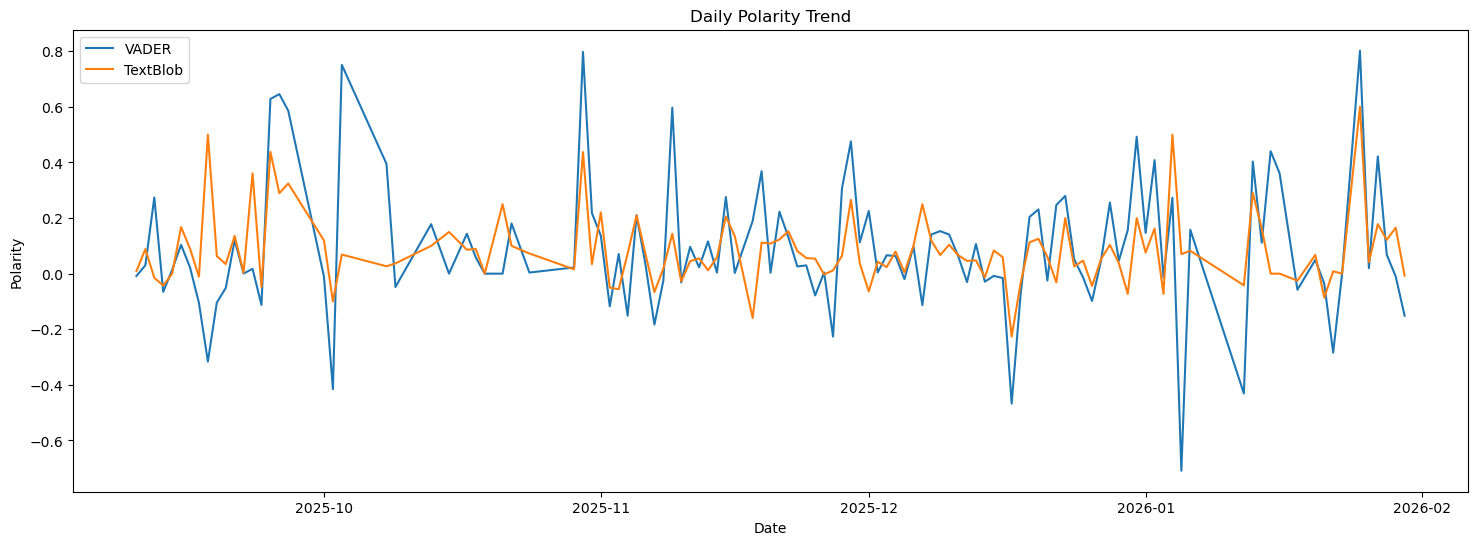

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize = (18,6))

plt.plot(df5['date'], df5['VADER'], label = 'VADER')
plt.plot(df5['date'], df5['TextBlob'], label = 'TextBlob')

plt.xlabel('Date')
plt.ylabel('Polarity')
plt.title('Daily Polarity Trend')
plt.legend()

plt.show()

#### Interpreting the Time-Series Plots

Because the numerical scores produced by `VADER` and `TextBlob` are not directly comparable, I focus primarily on temporal trends. As shown in the plot, sentiment in comments on economy-related news videos from the YouTube CNN and Fox News channels fluctuates frequently around a neutral baseline over time. There is no clear period in which discussions are consistently dominated by either positive or negative sentiment.

That said, some time windows show noticeable shifts. For example,sentiment turns more positive around Nov 2025, potentially aligning with policy easing signals (rate cut in late Oct) and perceptions of inflation stabilizing, encouraging more favorable audience reactions. In contrast, early Jan 2026 shows more negative sentiment, plausibly tied to heightened policy uncertainty, including tariff-related headlines and unclear rate-cut expectations. Because my keyword selection also includes job-market-related terms, shifts in labor market narratives are likely embedded in these sentiment patterns, meaning that public reactions to employment news are partially captured in the observed fluctuations.

Another observation is that the polarity trends generated by `VADER` and `TextBlob` move in broadly similar directions over time. This consistency suggests that the major sentiment shifts visible in the plot likely reflect genuine changes in how viewers respond to economic news topics.

More broadly, the mixed sentiment pattern aligns with the nature of the economy as a discussion topic. Economic issues are inherently multifaceted: individuals from different income levels, professional backgrounds, and personal circumstances may interpret economic conditions differently. Some viewers may focus on global markets, others on job opportunities or cost of living, while others react to policy debates. Because the keywords I selected cover these diverse aspects, the overall discussion naturally reflects mixed emotional responses, rather than a clear one-sided narrative.

Finally, I observe that `VADER` shows stronger volatility compared to `TextBlob`. Although the two methods operate on different scoring logics, both share a (-1,1) range. The larger swings in `VADER` likely reflect its sensitivity to informal social-media language. This observation is consistent with my earlier findings that `VADER` captures social media–style expressions more effectively than `TextBlob`.